In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

In [2]:
GCM_name_list =  ['MPI-ESM1-2-HR','EC-Earth3', 'FGOALS-g3','INM-CM5-0','INM-CM4-8','MRI-ESM2-0','BCC-CSM2-MR']
file_name_list = ['1_hsg_imputMF','2_dsk_imputMF','3_xhl_imputMF','4_slglk_imputMF','5_kq_imputMF','6_wlwt_imputMF','7_tgzlk_imputMF']

ssp126 1_hsg_imputMF 1.915752160933428e-05
ssp126 1_hsg_imputMF 2.0561582403596072e-05 None
ssp245 1_hsg_imputMF 1.944004426979183e-05
ssp245 1_hsg_imputMF 2.090090913816351e-05 None
ssp370 1_hsg_imputMF 1.9445515489213674e-05
ssp370 1_hsg_imputMF 2.0993213094397326e-05 None
ssp585 1_hsg_imputMF 1.933259394488845e-05
ssp585 1_hsg_imputMF 2.0926741658443243e-05 None
ssp126 2_dsk_imputMF 1.6527239210756678e-05
ssp126 2_dsk_imputMF 1.316602294500694e-05 None
ssp245 2_dsk_imputMF 1.660518792418865e-05
ssp245 2_dsk_imputMF 1.3486146853843348e-05 None
ssp370 2_dsk_imputMF 1.71199749164171e-05
ssp370 2_dsk_imputMF 1.4619739508841441e-05 None
ssp585 2_dsk_imputMF 1.6899983988482284e-05
ssp585 2_dsk_imputMF 1.4117406056804085e-05 None
ssp126 3_xhl_imputMF 1.879215005073482e-05
ssp126 3_xhl_imputMF 1.494494107479216e-05 None
ssp245 3_xhl_imputMF 1.877020696627016e-05
ssp245 3_xhl_imputMF 1.518416037159552e-05 None
ssp370 3_xhl_imputMF 1.8981860696320164e-05
ssp370 3_xhl_imputMF 1.531052505347759

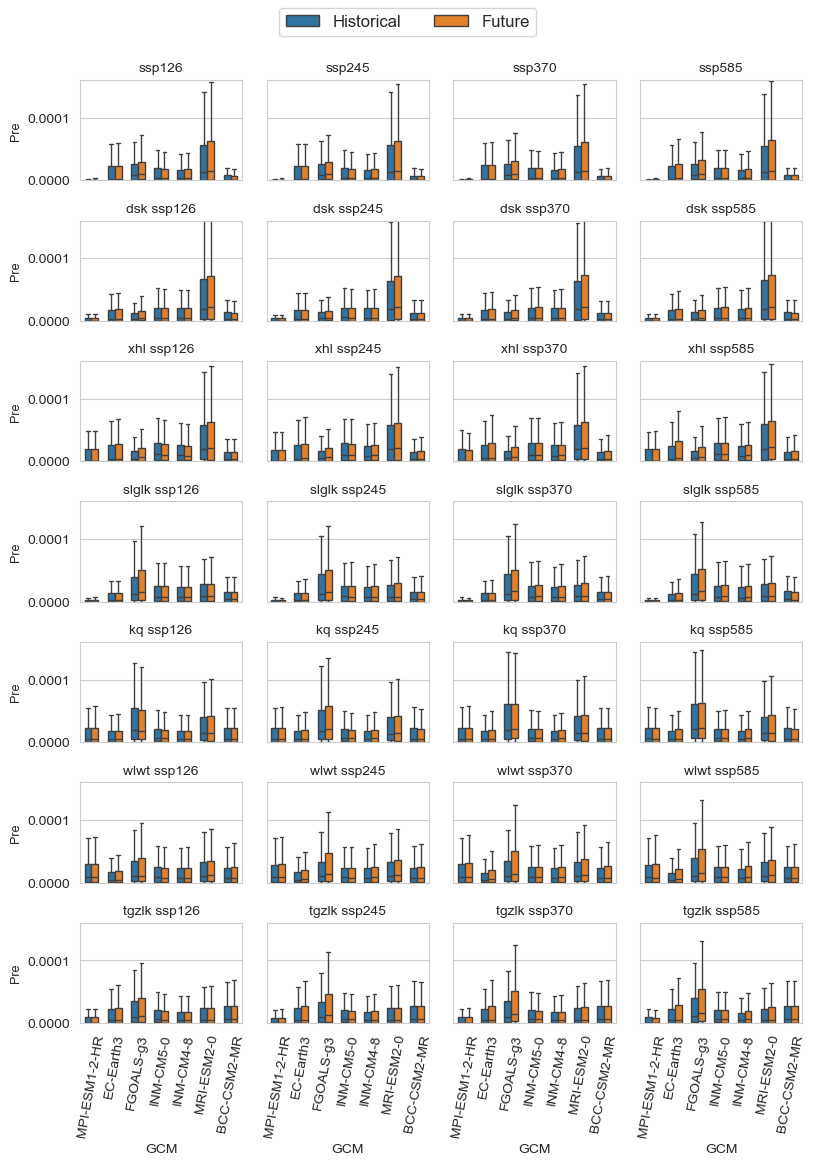

In [4]:
fig, axes = plt.subplots(7, 4, figsize=(8.27, 11.69), sharey=False)

scenario_list = ['ssp126', 'ssp245', 'ssp370', 'ssp585']

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split("_")[1]

    for j, scenario in enumerate(scenario_list):

        # =============== Build dataframe for this station & scenario ===============
        records = []

        for GCM_name in GCM_name_list:

            file_path = f"F:\\geodata\\river_runoff_obs - 副本\\{file_name}_{GCM_name}_{scenario}_r1i1p1f1_daily.csv"
            if not os.path.exists(file_path):
                continue

            df = pd.read_csv(file_path, index_col=0)
            df.index = pd.to_datetime(df.index)
            df = df[df.index > '1999-12-31']

            hist_df = df[df.index < '2020-01-01']
            future_df = df[df.index >= '2020-01-01']

            # Historical
            for val in hist_df['pre'].values:
                records.append({
                    'Station': abbre,
                    'Scenario': scenario,
                    'GCM': GCM_name,
                    'Period': 'Historical',
                    'Pre': val
                })

            # Future
            for val in future_df['pre'].values:
                records.append({
                    'Station': abbre,
                    'Scenario': scenario,
                    'GCM': GCM_name,
                    'Period': 'Future',
                    'Pre': val
                })

        scenario_df = pd.DataFrame(records)

        # =============== Plot into subplot ===============
        ax = axes[i, j]

        sns.boxplot(
            data=scenario_df,
            x='GCM',
            y='Pre',
            hue='Period',
            showfliers=False,
            width=0.6,
            ax=ax
        )
        print(scenario, file_name, scenario_df.loc[(scenario_df['Period']=='Historical') & (scenario_df['GCM']=='FGOALS-g3'), 'Pre'].mean(),print(scenario, file_name, scenario_df.loc[scenario_df['Period']=='Historical', 'Pre'].mean())
)

        # ===== Titles: Only first column keeps row titles =====
        ax.set_title(f"{abbre} {scenario}", fontsize=10)   # station name

        if j == 0:
            ax.set_ylabel("Pre", fontsize=9)
        else:
            ax.set_yticklabels([])
            ax.set_ylabel("")

        # ===== Column titles: Only top row shows scenario names =====
        if i == 0:
            ax.set_title(scenario, fontsize=10)

        # ===== X labels: Only bottom row keeps x labels =====
        if i == 6:  # last row
            ax.tick_params(axis='x', rotation=80)
            ax.set_xlabel("GCM")
        else:
            ax.set_xlabel("")
            ax.set_xticklabels([])

        # Remove duplicate legends inside subplots
        ax.get_legend().remove()
        ax.set_ylim(0, 0.00016)


# Show legend once
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [5]:
scenario_df

,Station,Scenario,GCM,Period,Pre
0,tgzlk,ssp585,MPI-ESM1-2-HR,Historical,1.970562e-07
1,tgzlk,ssp585,MPI-ESM1-2-HR,Historical,6.639550e-06
2,tgzlk,ssp585,MPI-ESM1-2-HR,Historical,2.029755e-05
3,tgzlk,ssp585,MPI-ESM1-2-HR,Historical,2.461020e-08
4,tgzlk,ssp585,MPI-ESM1-2-HR,Historical,6.457674e-06
...,...,...,...,...,...
281774,tgzlk,ssp585,BCC-CSM2-MR,Future,3.943426e-29
281775,tgzlk,ssp585,BCC-CSM2-MR,Future,3.971801e-29
281776,tgzlk,ssp585,BCC-CSM2-MR,Future,8.340059e-08
281777,tgzlk,ssp585,BCC-CSM2-MR,Future,1.297996e-06


In [6]:
scenario_df[scenario_df['Period'] == 'Historical']['Pre'].mean()

np.float64(2.1369227796612985e-05)

In [7]:
scenario_df

,Station,Scenario,GCM,Period,Pre
0,tgzlk,ssp585,MPI-ESM1-2-HR,Historical,1.970562e-07
1,tgzlk,ssp585,MPI-ESM1-2-HR,Historical,6.639550e-06
2,tgzlk,ssp585,MPI-ESM1-2-HR,Historical,2.029755e-05
3,tgzlk,ssp585,MPI-ESM1-2-HR,Historical,2.461020e-08
4,tgzlk,ssp585,MPI-ESM1-2-HR,Historical,6.457674e-06
...,...,...,...,...,...
281774,tgzlk,ssp585,BCC-CSM2-MR,Future,3.943426e-29
281775,tgzlk,ssp585,BCC-CSM2-MR,Future,3.971801e-29
281776,tgzlk,ssp585,BCC-CSM2-MR,Future,8.340059e-08
281777,tgzlk,ssp585,BCC-CSM2-MR,Future,1.297996e-06


KeyboardInterrupt: 

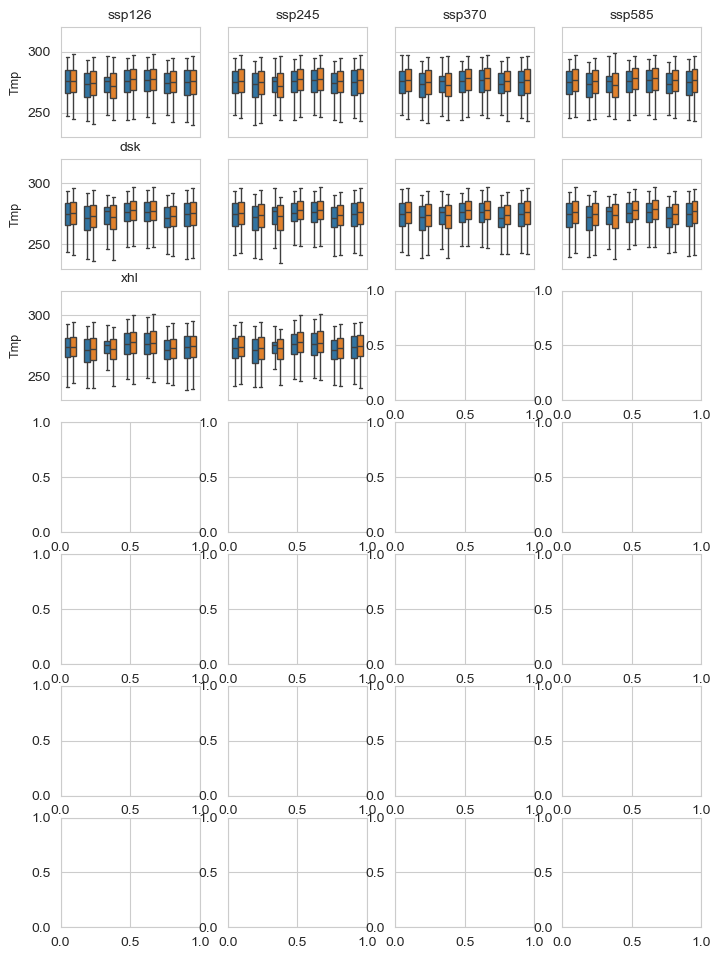

In [8]:
fig, axes = plt.subplots(7, 4, figsize=(8.27, 11.69), sharey=False)

scenario_list = ['ssp126', 'ssp245', 'ssp370', 'ssp585']

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split("_")[1]

    for j, scenario in enumerate(scenario_list):

        # =============== Build dataframe for this station & scenario ===============
        records = []

        for GCM_name in GCM_name_list:

            file_path = f"F:\\geodata\\river_runoff_obs - 副本\\{file_name}_{GCM_name}_{scenario}_r1i1p1f1_daily.csv"
            if not os.path.exists(file_path):
                print('not exist')
                continue

            df = pd.read_csv(file_path, index_col=0)
            df.index = pd.to_datetime(df.index)
            df = df[df.index > '1999-12-31']

            hist_df = df[df.index < '2020-01-01']
            future_df = df[df.index >= '2020-01-01']

            # Historical
            for val in hist_df['tm'].values:
                records.append({
                    'Station': abbre,
                    'Scenario': scenario,
                    'GCM': GCM_name,
                    'Period': 'Historical',
                    'Tmp': val
                })

            # Future
            for val in future_df['tm'].values:
                records.append({
                    'Station': abbre,
                    'Scenario': scenario,
                    'GCM': GCM_name,
                    'Period': 'Future',
                    'Tmp': val
                })

        scenario_df = pd.DataFrame(records)

        # =============== Plot into subplot ===============
        ax = axes[i, j]

        sns.boxplot(
            data=scenario_df,
            x='GCM',
            y='Tmp',
            hue='Period',
            showfliers=False,
            width=0.6,
            ax=ax
        )

        # ===== Titles: Only first column keeps row titles =====
        if j == 0:
            ax.set_ylabel("Tmp", fontsize=9)
            ax.set_title(f"{abbre}", fontsize=10)   # station name

        else:
            ax.set_ylabel("")
            ax.set_title("")
            ax.set_yticklabels([])

        # ===== Column titles: Only top row shows scenario names =====
        if i == 0:
            ax.set_title(scenario, fontsize=10)

        # ===== X labels: Only bottom row keeps x labels =====
        if i == 6:  # last row
            ax.tick_params(axis='x', rotation=80)
            ax.set_xlabel("GCM")
        else:
            ax.set_xlabel("")
            ax.set_xticklabels([])

        # Remove duplicate legends inside subplots
        ax.get_legend().remove()
        ax.set_ylim(230, 320)


# Show legend once
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


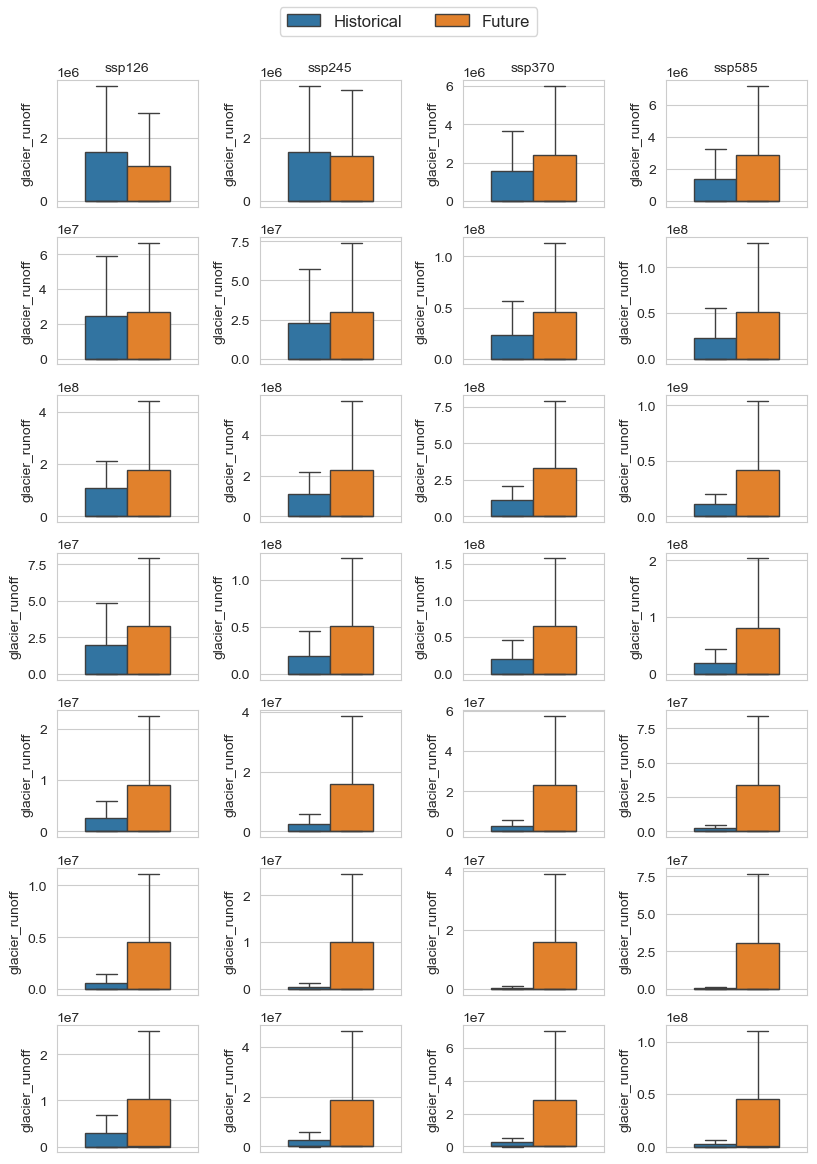

In [10]:
fig, axes = plt.subplots(7, 4, figsize=(8.27, 11.69), sharey=False)

scenario_list = ['ssp126', 'ssp245', 'ssp370', 'ssp585']

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split("_")[1]

    for j, scenario in enumerate(scenario_list):

        # =============== Build dataframe for this station & scenario ===============
        records = []

        for GCM_name in [GCM_name_list[0]]:

            file_path = f"F:\\geodata\\river_runoff_obs - 副本\\{file_name}_{GCM_name}_{scenario}_r1i1p1f1_mon.csv"
            if not os.path.exists(file_path):
                print('not exist')
                continue

            df = pd.read_csv(file_path, index_col='time')
            df.index = pd.to_datetime(df.index)
            df = df[df.index > '1999-12-31']

            hist_df = df[df.index < '2015-01-01']
            future_df = df[df.index >= '2015-01-01']

            # Historical
            for val in hist_df['gr'].values:
                records.append({
                    'Station': abbre,
                    'Scenario': scenario,
                    'GCM': GCM_name,
                    'Period': 'Historical',
                    'glacier_runoff': val
                })

            # Future
            for val in future_df['gr'].values:
                records.append({
                    'Station': abbre,
                    'Scenario': scenario,
                    'GCM': GCM_name,
                    'Period': 'Future',
                    'glacier_runoff': val
                })

        scenario_df = pd.DataFrame(records)

        # =============== Plot into subplot ===============
        ax = axes[i, j]

        sns.boxplot(
            data=scenario_df,
            x='GCM',
            y='glacier_runoff',
            hue='Period',
            showfliers=False,
            width=0.6,
            ax=ax
        )

        # # ===== Titles: Only first column keeps row titles =====
        # if j == 0:
        #     ax.set_ylabel("glacier_runoff", fontsize=9)
        #     ax.set_title(f"{abbre}", fontsize=10)   # station name
        #
        # else:
        #     ax.set_ylabel("")
        #     ax.set_title("")
        #     ax.set_yticklabels([])

        # ===== Column titles: Only top row shows scenario names =====
        if i == 0:
            ax.set_title(scenario, fontsize=10)

        ax.set_xlabel("")
        ax.set_xticklabels([])

        # Remove duplicate legends inside subplots
        ax.get_legend().remove()
        # ax.set_ylim(0, 320)


# Show legend once
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


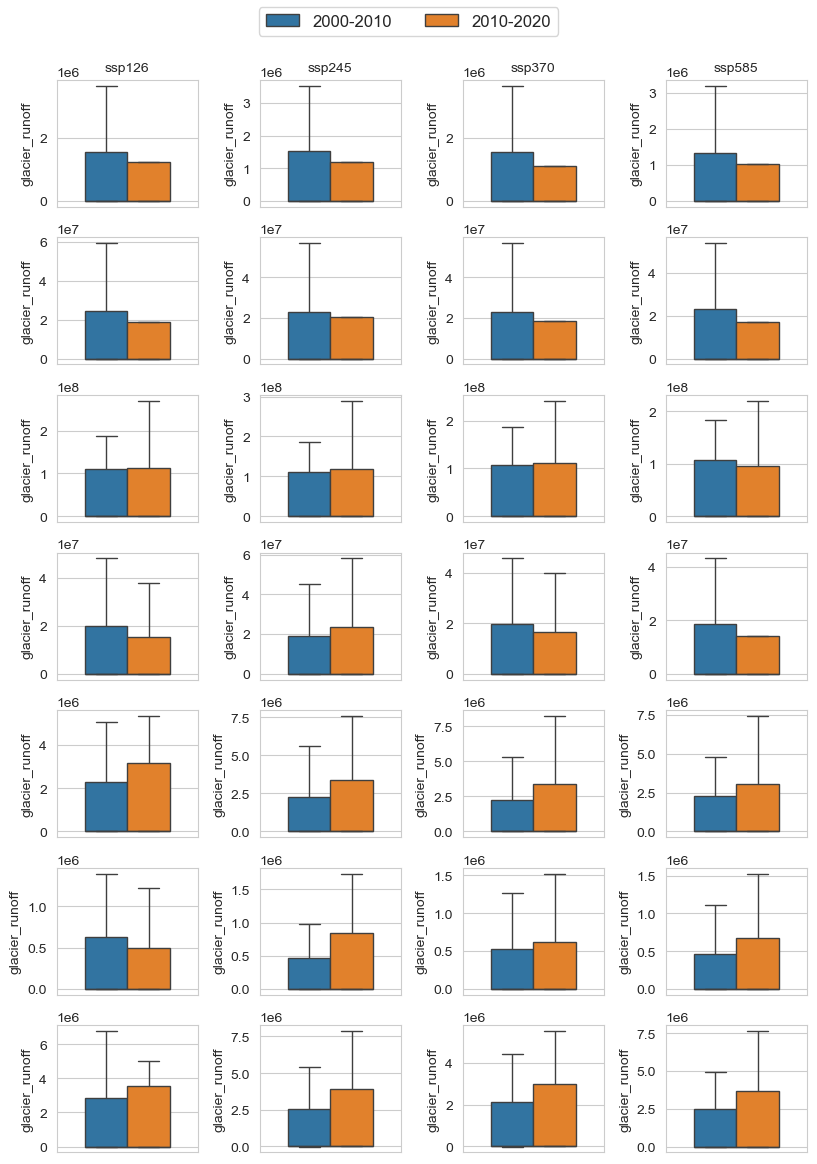

In [3]:
fig, axes = plt.subplots(7, 4, figsize=(8.27, 11.69), sharey=False)

scenario_list = ['ssp126', 'ssp245', 'ssp370', 'ssp585']

for i, file_name in enumerate(file_name_list):
    abbre = file_name.split("_")[1]

    for j, scenario in enumerate(scenario_list):

        # =============== Build dataframe for this station & scenario ===============
        records = []

        for GCM_name in [GCM_name_list[0]]:

            file_path = f"F:\\geodata\\river_runoff_obs - 副本\\{file_name}_{GCM_name}_{scenario}_r1i1p1f1_mon.csv"
            if not os.path.exists(file_path):
                print('not exist')
                continue

            df = pd.read_csv(file_path, index_col='time')
            df.index = pd.to_datetime(df.index)
            df = df[df.index > '1999-12-31']

            hist_df = df[df.index < '2011-01-01']
            future_df = df[(df.index >= '2011-01-01') & (df.index <= '2020-12-31')]


            # Historical
            for val in hist_df['gr'].values:
                records.append({
                    'Station': abbre,
                    'Scenario': scenario,
                    'GCM': GCM_name,
                    'Period': '2000-2010',
                    'glacier_runoff': val
                })

            # Future
            for val in future_df['gr'].values:
                records.append({
                    'Station': abbre,
                    'Scenario': scenario,
                    'GCM': GCM_name,
                    'Period': '2010-2020',
                    'glacier_runoff': val
                })

        scenario_df = pd.DataFrame(records)

        # =============== Plot into subplot ===============
        ax = axes[i, j]

        sns.boxplot(
            data=scenario_df,
            x='GCM',
            y='glacier_runoff',
            hue='Period',
            showfliers=False,
            width=0.6,
            ax=ax
        )

        # # ===== Titles: Only first column keeps row titles =====
        # if j == 0:
        #     ax.set_ylabel("glacier_runoff", fontsize=9)
        #     ax.set_title(f"{abbre}", fontsize=10)   # station name
        #
        # else:
        #     ax.set_ylabel("")
        #     ax.set_title("")
        #     ax.set_yticklabels([])

        # ===== Column titles: Only top row shows scenario names =====
        if i == 0:
            ax.set_title(scenario, fontsize=10)

        ax.set_xlabel("")
        ax.set_xticklabels([])

        # Remove duplicate legends inside subplots
        ax.get_legend().remove()
        # ax.set_ylim(0, 320)


# Show legend once
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [10]:
df

,Unnamed: 0,dis,tm,pre,ep,gr
time,,,,,,
2000-02-01,1,9.846207,255.653892,8.649696e-06,30.532414,0.000000e+00
2000-03-01,2,10.148387,261.504189,1.474780e-05,54.243871,0.000000e+00
2000-04-01,3,13.583333,269.148594,2.186497e-05,90.959333,0.000000e+00
2000-05-01,4,52.506452,275.253316,1.735691e-05,132.774194,4.824613e+03
2000-06-01,5,132.123333,277.919295,2.776609e-05,173.096000,4.911962e+06
...,...,...,...,...,...,...
2100-08-01,1207,NaN,284.957848,2.006770e-05,NaN,2.711480e+09
2100-09-01,1208,NaN,281.034148,5.577757e-07,NaN,6.585741e+08
2100-10-01,1209,NaN,279.011076,2.814651e-06,NaN,3.634251e+06


In [11]:
df

,Unnamed: 0,dis,tm,pre,ep,gr
time,,,,,,
2000-02-01,1,9.846207,255.653892,8.649696e-06,30.532414,0.000000e+00
2000-03-01,2,10.148387,261.504189,1.474780e-05,54.243871,0.000000e+00
2000-04-01,3,13.583333,269.148594,2.186497e-05,90.959333,0.000000e+00
2000-05-01,4,52.506452,275.253316,1.735691e-05,132.774194,4.824613e+03
2000-06-01,5,132.123333,277.919295,2.776609e-05,173.096000,4.911962e+06
...,...,...,...,...,...,...
2100-08-01,1207,NaN,284.957848,2.006770e-05,NaN,2.711480e+09
2100-09-01,1208,NaN,281.034148,5.577757e-07,NaN,6.585741e+08
2100-10-01,1209,NaN,279.011076,2.814651e-06,NaN,3.634251e+06


In [12]:
df

,Unnamed: 0,dis,tm,pre,ep,gr
time,,,,,,
2000-02-01,1,9.846207,255.653892,8.649696e-06,30.532414,0.000000e+00
2000-03-01,2,10.148387,261.504189,1.474780e-05,54.243871,0.000000e+00
2000-04-01,3,13.583333,269.148594,2.186497e-05,90.959333,0.000000e+00
2000-05-01,4,52.506452,275.253316,1.735691e-05,132.774194,4.824613e+03
2000-06-01,5,132.123333,277.919295,2.776609e-05,173.096000,4.911962e+06
...,...,...,...,...,...,...
2100-08-01,1207,NaN,284.957848,2.006770e-05,NaN,2.711480e+09
2100-09-01,1208,NaN,281.034148,5.577757e-07,NaN,6.585741e+08
2100-10-01,1209,NaN,279.011076,2.814651e-06,NaN,3.634251e+06
